In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Linear Regression

## 1. Data

In [2]:
# read data
cars = pd.read_csv('turboaz.csv')

In [3]:
# get columns and preprocess features
X1_cars = cars['Yurush'].str.replace(r'\D', '', regex=True).astype(float).values
X2_cars = cars['Buraxilish ili'].astype(float).values
Y_cars = (cars['Qiymet'].str.replace(r'\D', '', regex=True).astype(float)
          * np.where(cars['Qiymet'].str.contains('$', regex=False), 1.7, 1)).values

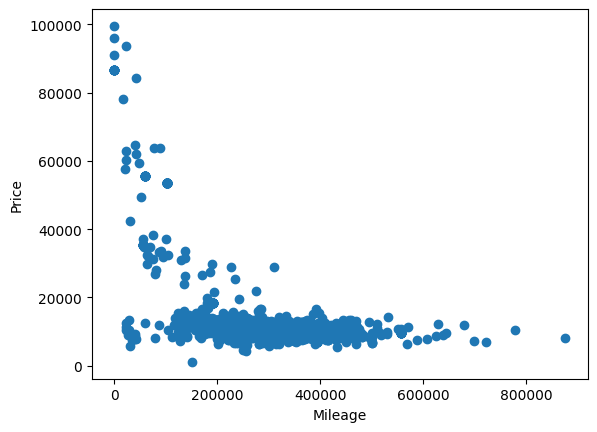

In [4]:
# plot X1 and Y
plt.scatter(X1_cars, Y_cars)
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

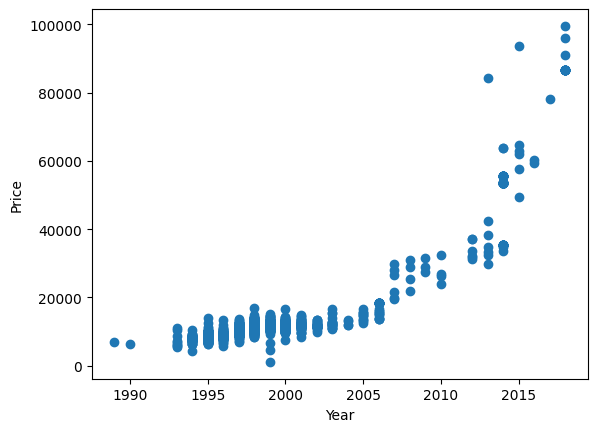

In [5]:
# plot X2 and Y
plt.scatter(X2_cars, Y_cars)
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

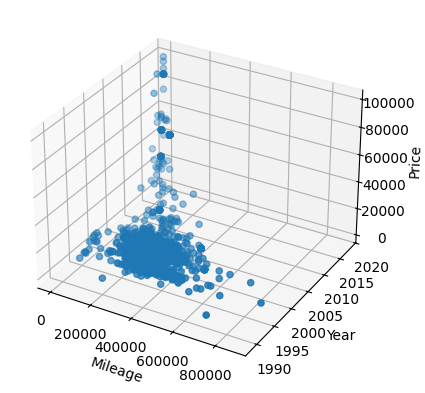

In [6]:
# plot X1, X2 and Y
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1_cars, X2_cars, Y_cars)

ax.set_xlabel("Mileage")
ax.set_ylabel("Year")
ax.set_zlabel("Price")

plt.show()

In [7]:
# create copies of original for later use
X1_cars_copy = X1_cars.copy()
X2_cars_copy = X2_cars.copy()
Y_cars_copy = Y_cars.copy()

# normalize data using z-score
X1_cars = (X1_cars - X1_cars.mean()) / X1_cars.std()
X2_cars = (X2_cars - X2_cars.mean()) / X2_cars.std()
Y_cars = (Y_cars - Y_cars.mean()) / Y_cars.std()

## 2. Linear regression from scratch

In [8]:
# implement linear hypothesis function
def h_linear(X, T):
    return np.dot(X, T)

In [9]:
# implement cost function
def J_linear(h, Y):
    return np.sum((h - Y) ** 2) / (2 * len(Y))

In [10]:
# create data matrix with three features (add bias feature)
X0_cars = np.ones(len(X1_cars))
X_cars = np.column_stack((X0_cars, X1_cars, X2_cars))

In [11]:
# initialize parameters vector to zeros
T_cars = np.zeros(3)

In [12]:
# set learning rate and number of iterations
alpha_cars = 0.001
iterations_cars = 10000

In [13]:
# implement gradient descent
def gradient_descent(X, Y, T, h_function, J_function, alpha, iterations):
    # store costs for plotting
    cost_history = [0] * iterations
    m = len(Y)

    # update parameters
    for iteration in range(iterations):
        h = h_function(X, T)

        # print useful information
        if iteration % 1000 == 0: 
            print("Iteration #%d" % iteration)         
            print(J_function(h, Y))

        # calculate gradient
        gradient = np.dot(X.T, h - Y) / m
        
        # update parameters
        T -= alpha * gradient

        # calculate new cost and store
        cost = J_function(h_function(X, T), Y)
        cost_history[iteration] = cost

    return T, cost_history

In [14]:
# get optimized parameter values and cost history
optimal_T_cars, cost_history_cars = gradient_descent(X_cars,
                                                     Y_cars,
                                                     T_cars,
                                                     h_linear,
                                                     J_linear,
                                                     alpha_cars,
                                                     iterations_cars)

Iteration #0
0.5
Iteration #1000
0.14542189891677568
Iteration #2000
0.11732322938438836
Iteration #3000
0.11068716976538699
Iteration #4000
0.10810351437919824
Iteration #5000
0.10701898775326069
Iteration #6000
0.10656005344494976
Iteration #7000
0.10636568773598895
Iteration #8000
0.10628336395194486
Iteration #9000
0.10624849533470686


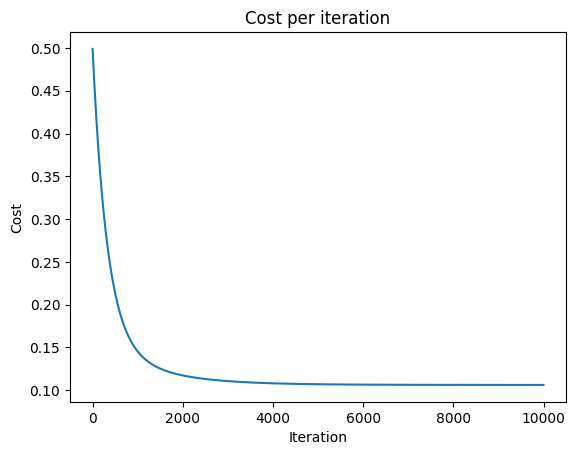

In [15]:
# plot the cost as a function of iterations
plt.plot(cost_history_cars)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost per iteration')
plt.show()

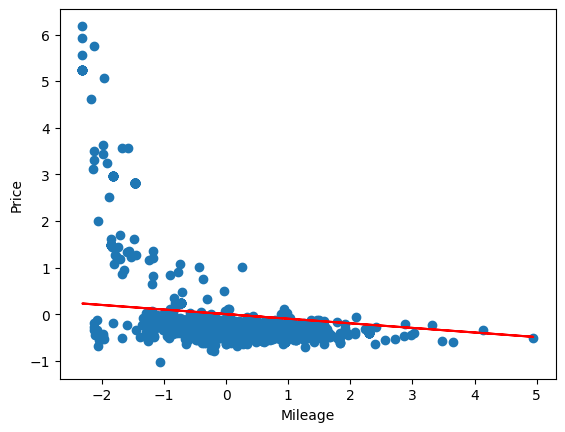

In [16]:
# plot points of X1 and Y
plt.scatter(X1_cars, Y_cars)
plt.xlabel('Mileage')
plt.ylabel('Price')

# make predictions and plot
predictions_cars = h_linear(np.column_stack((X0_cars, X1_cars)), optimal_T_cars[:2])
plt.plot(X1_cars, predictions_cars, c='r')
plt.show()

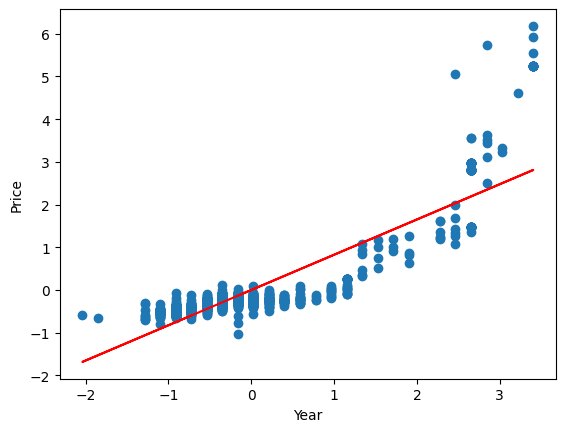

In [17]:
# plot points of X2 and Y
plt.scatter(X2_cars, Y_cars)
plt.xlabel('Year')
plt.ylabel('Price')

# make predictions and plot
predictions_cars = h_linear(np.column_stack((X0_cars, X2_cars)), optimal_T_cars[[0, 2]])
plt.plot(X2_cars, predictions_cars, c='r')

plt.show()

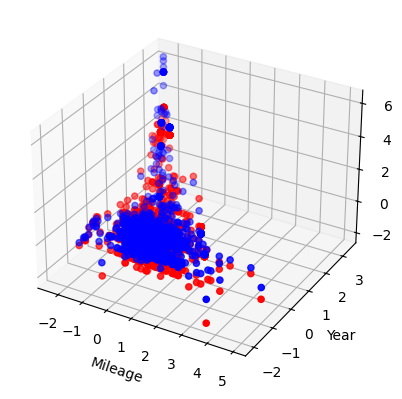

In [18]:
# plot X1, X2, Y, and predicted Y
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X1_cars, X2_cars, Y_cars, c='b')

predictions_cars = h_linear(X_cars, optimal_T_cars)
ax.scatter(X1_cars, X2_cars, predictions_cars, c='r')

ax.set_xlabel("Mileage")
ax.set_ylabel("Year")
ax.set_zlabel("Price")

plt.show()

In [19]:
# make predictions
cars_predictions_scratch = h_linear(X_cars, optimal_T_cars)

In [20]:
# evaluate model
print(mean_squared_error(Y_cars, cars_predictions_scratch))
print(r2_score(Y_cars, cars_predictions_scratch))

0.21246745311733542
0.7875325468826646


In [21]:
# predict the price for the given car
mileage = 240000
year = 2000
actual_price = 11500

# normalize
mileage = (mileage - X1_cars_copy.mean()) / X1_cars_copy.std()
year = (year - X2_cars_copy.mean()) / X2_cars_copy.std()
actual_price = (actual_price - Y_cars_copy.mean()) / Y_cars_copy.std()

# predict
predicted_price = h_linear([1, mileage, year], optimal_T_cars)

# revert back to original range and print the prediction
print(predicted_price * Y_cars_copy.std() + Y_cars_copy.mean())

15841.371386290646


In [22]:
# predict the price for the given car
mileage = 415558
year = 1996
actual_price = 8800

# normalize
mileage = (mileage - X1_cars_copy.mean()) / X1_cars_copy.std()
year = (year - X2_cars_copy.mean()) / X2_cars_copy.std()
actual_price = (actual_price - Y_cars_copy.mean()) / Y_cars_copy.std()

# predict
predicted_price = h_linear([1, mileage, year], optimal_T_cars)

# revert back to original price and print the prediction 
print(predicted_price * Y_cars_copy.std() + Y_cars_copy.mean())

5426.154789660532


## 3. Linear regression using library 

In [23]:
# create data matrix of two original features
X_train_cars = np.column_stack((X1_cars_copy, X2_cars_copy))

In [24]:
# create linear regression model instance and train it
regression_model = LinearRegression()
regression_model.fit(X_train_cars, Y_cars_copy)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# make predictions
cars_predictions_library = regression_model.predict(X_train_cars)

In [26]:
# evaluate model
print(mean_squared_error(Y_cars_copy, cars_predictions_library))
print(r2_score(Y_cars_copy, cars_predictions_library))

39556044.57986179
0.7875542502164035


In [27]:
# create data matrix for test cars and predict
X_test_cars = [[240000, 2000], [415558, 1996]]
print(regression_model.predict(X_test_cars))

[15820.54127243  5453.69414862]


## 4. Linear regression using normal equation

In [28]:
# implement normal equation and apply it to normalized data
T_normaleq = np.linalg.inv(X_cars.T @ X_cars) @ X_cars.T @ Y_cars

In [29]:
print(T_normaleq)

[ 1.69707998e-14 -9.33437483e-02  8.30867464e-01]


# Logistic Regression

## 1. Data

In [30]:
# read data
exams = pd.read_csv('exams.csv')

In [31]:
# get columns
X1_exams = exams['exam_1'].values
X2_exams = exams['exam_2'].values
Y_exams = exams['admitted'].values

In [32]:
# create copies of original for later use
X1_exams_copy = X1_exams.copy()
X2_exams_copy = X2_exams.copy()
Y_exams_copy = Y_exams.copy()

# scale data using min-max scaling
X1_exams = (X1_exams - X1_exams.min()) / (X1_exams.max() - X1_exams.min())
X2_exams = (X2_exams - X2_exams.min()) / (X2_exams.max() - X2_exams.min())

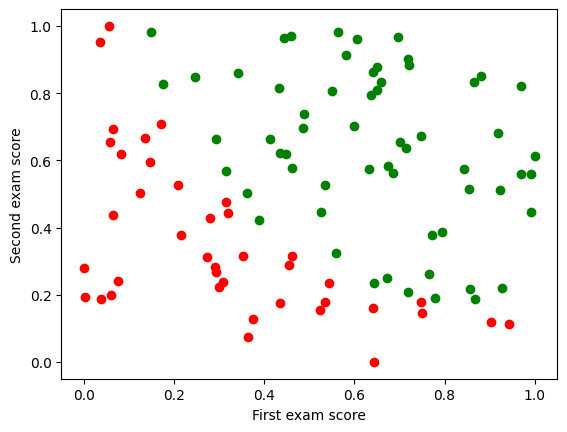

In [33]:
# plot points of X1, X2 and color-code labels
plt.xlabel('First exam score')
plt.ylabel('Second exam score')

plt.scatter(X1_exams[Y_exams == 1], X2_exams[Y_exams == 1], color = 'green')
plt.scatter(X1_exams[Y_exams == 0], X2_exams[Y_exams == 0], color = 'red')

## 2. Logistic regression from scratch 

In [34]:
# implement sigmoid hypothesis function
def h_logistic(X, T):
    return 1 / (1 + np.exp(-np.dot(X, T)))

In [35]:
# implement cost function
def J_logistic(h, Y):
    return -np.sum(Y * np.log(h) + (1 - Y) * np.log(1 - h)) / len(Y)

In [36]:
# create data matrix with three features (add bias feature)
X0_exams = np.ones(len(X1_exams))
X_exams = np.column_stack((X0_exams, X1_exams, X2_exams))

In [37]:
# initialize parameters vector to zeros
T_exams = np.zeros(3)

In [38]:
# set learning rate and number of iterations
alpha_exams = 0.1
iterations_exams = 10000

In [39]:
# get optimized parameter values and cost history
optimal_T_exams, cost_history_exams = gradient_descent(X_exams,
                                                       Y_exams,
                                                       T_exams,
                                                       h_logistic,
                                                       J_logistic,
                                                       alpha_exams,
                                                       iterations_exams)

Iteration #0
0.6931471805599453


Iteration #1000
0.3713254689168793
Iteration #2000
0.3036686574748253


Iteration #3000
0.2735199188771643
Iteration #4000
0.2563176712153076
Iteration #5000
0.24516491259484827
Iteration #6000
0.2373523282972159
Iteration #7000
0.23158889644988434
Iteration #8000
0.22717700431041685
Iteration #9000
0.2237048213667549


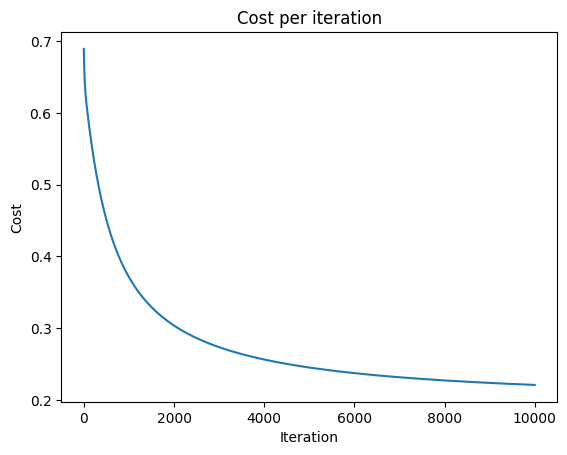

In [40]:
# plot the cost as a function of iterations
plt.plot(cost_history_exams)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost per iteration')
plt.show()

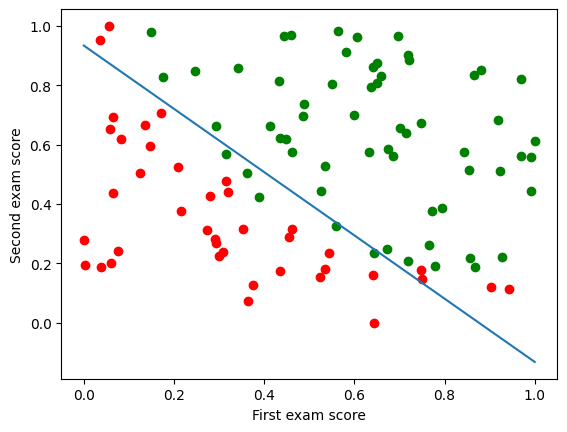

In [41]:
# plot points of X1, X2, and color-code labels
plt.xlabel('First exam score')
plt.ylabel('Second exam score')

plt.scatter(X1_exams[Y_exams == 1], X2_exams[Y_exams == 1], color = 'green')
plt.scatter(X1_exams[Y_exams == 0], X2_exams[Y_exams == 0], color = 'red')

# plot decision boundary
X_values = np.array([X1_exams.min(), X1_exams.max()])
Y_values = -(optimal_T_exams[0] + optimal_T_exams[1] * X_values) / optimal_T_exams[2]
plt.plot(X_values, Y_values)

In [42]:
# make predictions with threshold 0.5
exams_probabilities_scratch = h_logistic(X_exams, optimal_T_exams)
exams_predictions_scratch = np.where(exams_probabilities_scratch>=0.5, 1, 0)

In [43]:
# evaluate model
print(accuracy_score(Y_exams, exams_predictions_scratch))

0.89


In [44]:
# predict whether the following student passed
exam1 = 55
exam2 = 70

# scale
exam1 = (exam1 - X1_exams_copy.min())/(X1_exams_copy.max() - X1_exams_copy.min())
exam2 = (exam2 - X2_exams_copy.min())/(X2_exams_copy.max() - X2_exams_copy.min())

# predict
predicted_value = h_logistic([1, exam1, exam2], optimal_T_exams)
print(predicted_value)

0.5534893902055655


In [45]:
# predict whether the following student passed
exam1 = 40
exam2 = 60

# scale
exam1 = (exam1 - X1_exams_copy.min())/(X1_exams_copy.max() - X1_exams_copy.min())
exam2 = (exam2 - X2_exams_copy.min())/(X2_exams_copy.max() - X2_exams_copy.min())

# predict
predicted_value = h_logistic([1, exam1, exam2], optimal_T_exams)
print(predicted_value)

0.043984101139535034


## 3. Logistic regression using library 

In [46]:
# create data matrix of two original features
X_train_exams = np.column_stack((X1_exams_copy, X2_exams_copy))

In [47]:
# create logistic regression model instance and train it
model = LogisticRegression()
model.fit(X_train_exams, Y_exams_copy)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
# make predictions with library
exams_predictions_library = model.predict(X_train_exams)

In [49]:
# evaluate model
print(accuracy_score(Y_exams_copy, exams_predictions_library))

0.89


In [50]:
# create data matrix for test students and predict
X_test_exams = [[55, 70], [40, 60]]
print(model.predict_proba(X_test_exams))

[[0.42967107 0.57032893]
 [0.99186143 0.00813857]]
